#### Importaciones

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate, KFold, TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from joblib import dump, load

#### 1. Preparar datos

In [2]:
def load_data(folder, filename):
    route = os.path.join(folder, filename)
    data = pd.read_csv(route)
    return data


In [3]:
# Generales:
folder = "./datasets"
file_name_training = "gold_recovery_train.csv"
file_name_test = "gold_recovery_test.csv"

##### 1.1. Carga de datos

In [4]:
training_data = load_data(folder, file_name_training)
test_data = load_data(folder, file_name_test)

#### Explorar datos (EDA)

##### Exploracion inicial

In [5]:
training_data.head()

,date,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2016-01-15 00:00:00,6.055403,9.889648,5.507324,42.192020,70.541216,10.411962,0.895447,16.904297,2.143149,...,14.016835,-502.488007,12.099931,-504.715942,9.925633,-498.310211,8.079666,-500.470978,14.151341,-605.841980
1,2016-01-15 01:00:00,6.029369,9.968944,5.257781,42.701629,69.266198,10.462676,0.927452,16.634514,2.224930,...,13.992281,-505.503262,11.950531,-501.331529,10.039245,-500.169983,7.984757,-500.582168,13.998353,-599.787184
2,2016-01-15 02:00:00,6.055926,10.213995,5.383759,42.657501,68.116445,10.507046,0.953716,16.208849,2.257889,...,14.015015,-502.520901,11.912783,-501.133383,10.070913,-500.129135,8.013877,-500.517572,14.028663,-601.427363
3,2016-01-15 03:00:00,6.047977,9.977019,4.858634,42.689819,68.347543,10.422762,0.883763,16.532835,2.146849,...,14.036510,-500.857308,11.999550,-501.193686,9.970366,-499.201640,7.977324,-500.255908,14.005551,-599.996129
4,2016-01-15 04:00:00,6.148599,10.142511,4.939416,42.774141,66.927016,10.360302,0.792826,16.525686,2.055292,...,14.027298,-499.838632,11.953070,-501.053894,9.925709,-501.686727,7.894242,-500.356035,13.996647,-601.496691


In [6]:
training_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 16860 entries, 0 to 16859
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                16860 non-null  str    
 1   final.output.concentrate_ag                         16788 non-null  float64
 2   final.output.concentrate_pb                         16788 non-null  float64
 3   final.output.concentrate_sol                        16490 non-null  float64
 4   final.output.concentrate_au                         16789 non-null  float64
 5   final.output.recovery                               15339 non-null  float64
 6   final.output.tail_ag                                16794 non-null  float64
 7   final.output.tail_pb                                16677 non-null  float64
 8   final.output.tail_sol                               16715 non-null  float64
 9   final.

In [7]:
test_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5856 entries, 0 to 5855
Data columns (total 53 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   date                                        5856 non-null   str    
 1   primary_cleaner.input.sulfate               5554 non-null   float64
 2   primary_cleaner.input.depressant            5572 non-null   float64
 3   primary_cleaner.input.feed_size             5856 non-null   float64
 4   primary_cleaner.input.xanthate              5690 non-null   float64
 5   primary_cleaner.state.floatbank8_a_air      5840 non-null   float64
 6   primary_cleaner.state.floatbank8_a_level    5840 non-null   float64
 7   primary_cleaner.state.floatbank8_b_air      5840 non-null   float64
 8   primary_cleaner.state.floatbank8_b_level    5840 non-null   float64
 9   primary_cleaner.state.floatbank8_c_air      5840 non-null   float64
 10  primary_cleaner.state.f

In [8]:
training_data["date"] = pd.to_datetime(training_data["date"], format="%Y-%m-%d %H:%M:%S")
test_data["date"] = pd.to_datetime(test_data["date"], format="%Y-%m-%d %H:%M:%S")

#### Conclusiones de 1.1

- Se observan muchas variables innecesarias. Se recomienda filtrar el dataframe para que solo contenga lo relacionado al oro.
- Los datos presentan valores ausentes o nulos. 
- Se recomienda revisar si hay datos duplicados.
- Lo mejor es eliinar esas filas con valores ausentes. Hay suficientes datos para entrenar el modelo.
- Para el modelo lineal se recomienda usar un scaler para que los datos estén en el mismo orden de magnitud.

#### 1.2. Calculo de recovery

Comprueba que el cálculo de la recuperación sea correcto. Calcula la recuperación de la característica rougher.output.recovery mediante el conjunto de entrenamiento. Encuentra el EAM entre tus cálculos y los valores de la característica. Facilita los resultados.


In [9]:
# Crear un nuevo dataframe que contenga solo las columnas relacionadas con el Oro y los target de recuperacion (rougher.output.recovery y final.output.recovery)
columnas_de_interes = []
for column in training_data.columns:
    if "_au" in column:
        columnas_de_interes.append(column) 
    elif column == "rougher.output.recovery":
        columnas_de_interes.append(column)
    elif column == "final.output.recovery":
        columnas_de_interes.append(column)

df_rougher = training_data[columnas_de_interes]
df_rougher.info()

<class 'pandas.DataFrame'>
RangeIndex: 16860 entries, 0 to 16859
Data columns (total 13 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   final.output.concentrate_au                         16789 non-null  float64
 1   final.output.recovery                               15339 non-null  float64
 2   final.output.tail_au                                16794 non-null  float64
 3   primary_cleaner.output.concentrate_au               16778 non-null  float64
 4   primary_cleaner.output.tail_au                      16777 non-null  float64
 5   rougher.calculation.sulfate_to_au_concentrate       16833 non-null  float64
 6   rougher.calculation.floatbank10_sulfate_to_au_feed  16833 non-null  float64
 7   rougher.calculation.floatbank11_sulfate_to_au_feed  16833 non-null  float64
 8   rougher.input.feed_au                               16777 non-null  float64
 9   roughe

Conclusión del filtrado de datos:
- Las filas duplicadas eran las mismas que las filas con datos nulos.

Calcular los datos de la recuperación teórica de oro de acuerdo a la fórmula. Este cálculo se debe incluir como fila en los datos

Recuperacion = (C*(F-T))/(F*(C-T))

Este cálculo teórico permite obtener las 2 recuperaciones del proceso:

1. La recuperación del concentrado rougher (corresponde al 3 en la figura)
En este caso las variables significan lo siguiente:

- C -> rougher.ouput.concentrate_au
- F -> rougher.input.feed_au
- T -> rougher.output.tail_au

2. La recuperación del concentrado final (corresponde al 8 en la figura)

- C -> final.output.concentrate_au
- F -> rougher.input.feed_au
- T -> final.output.tail_au

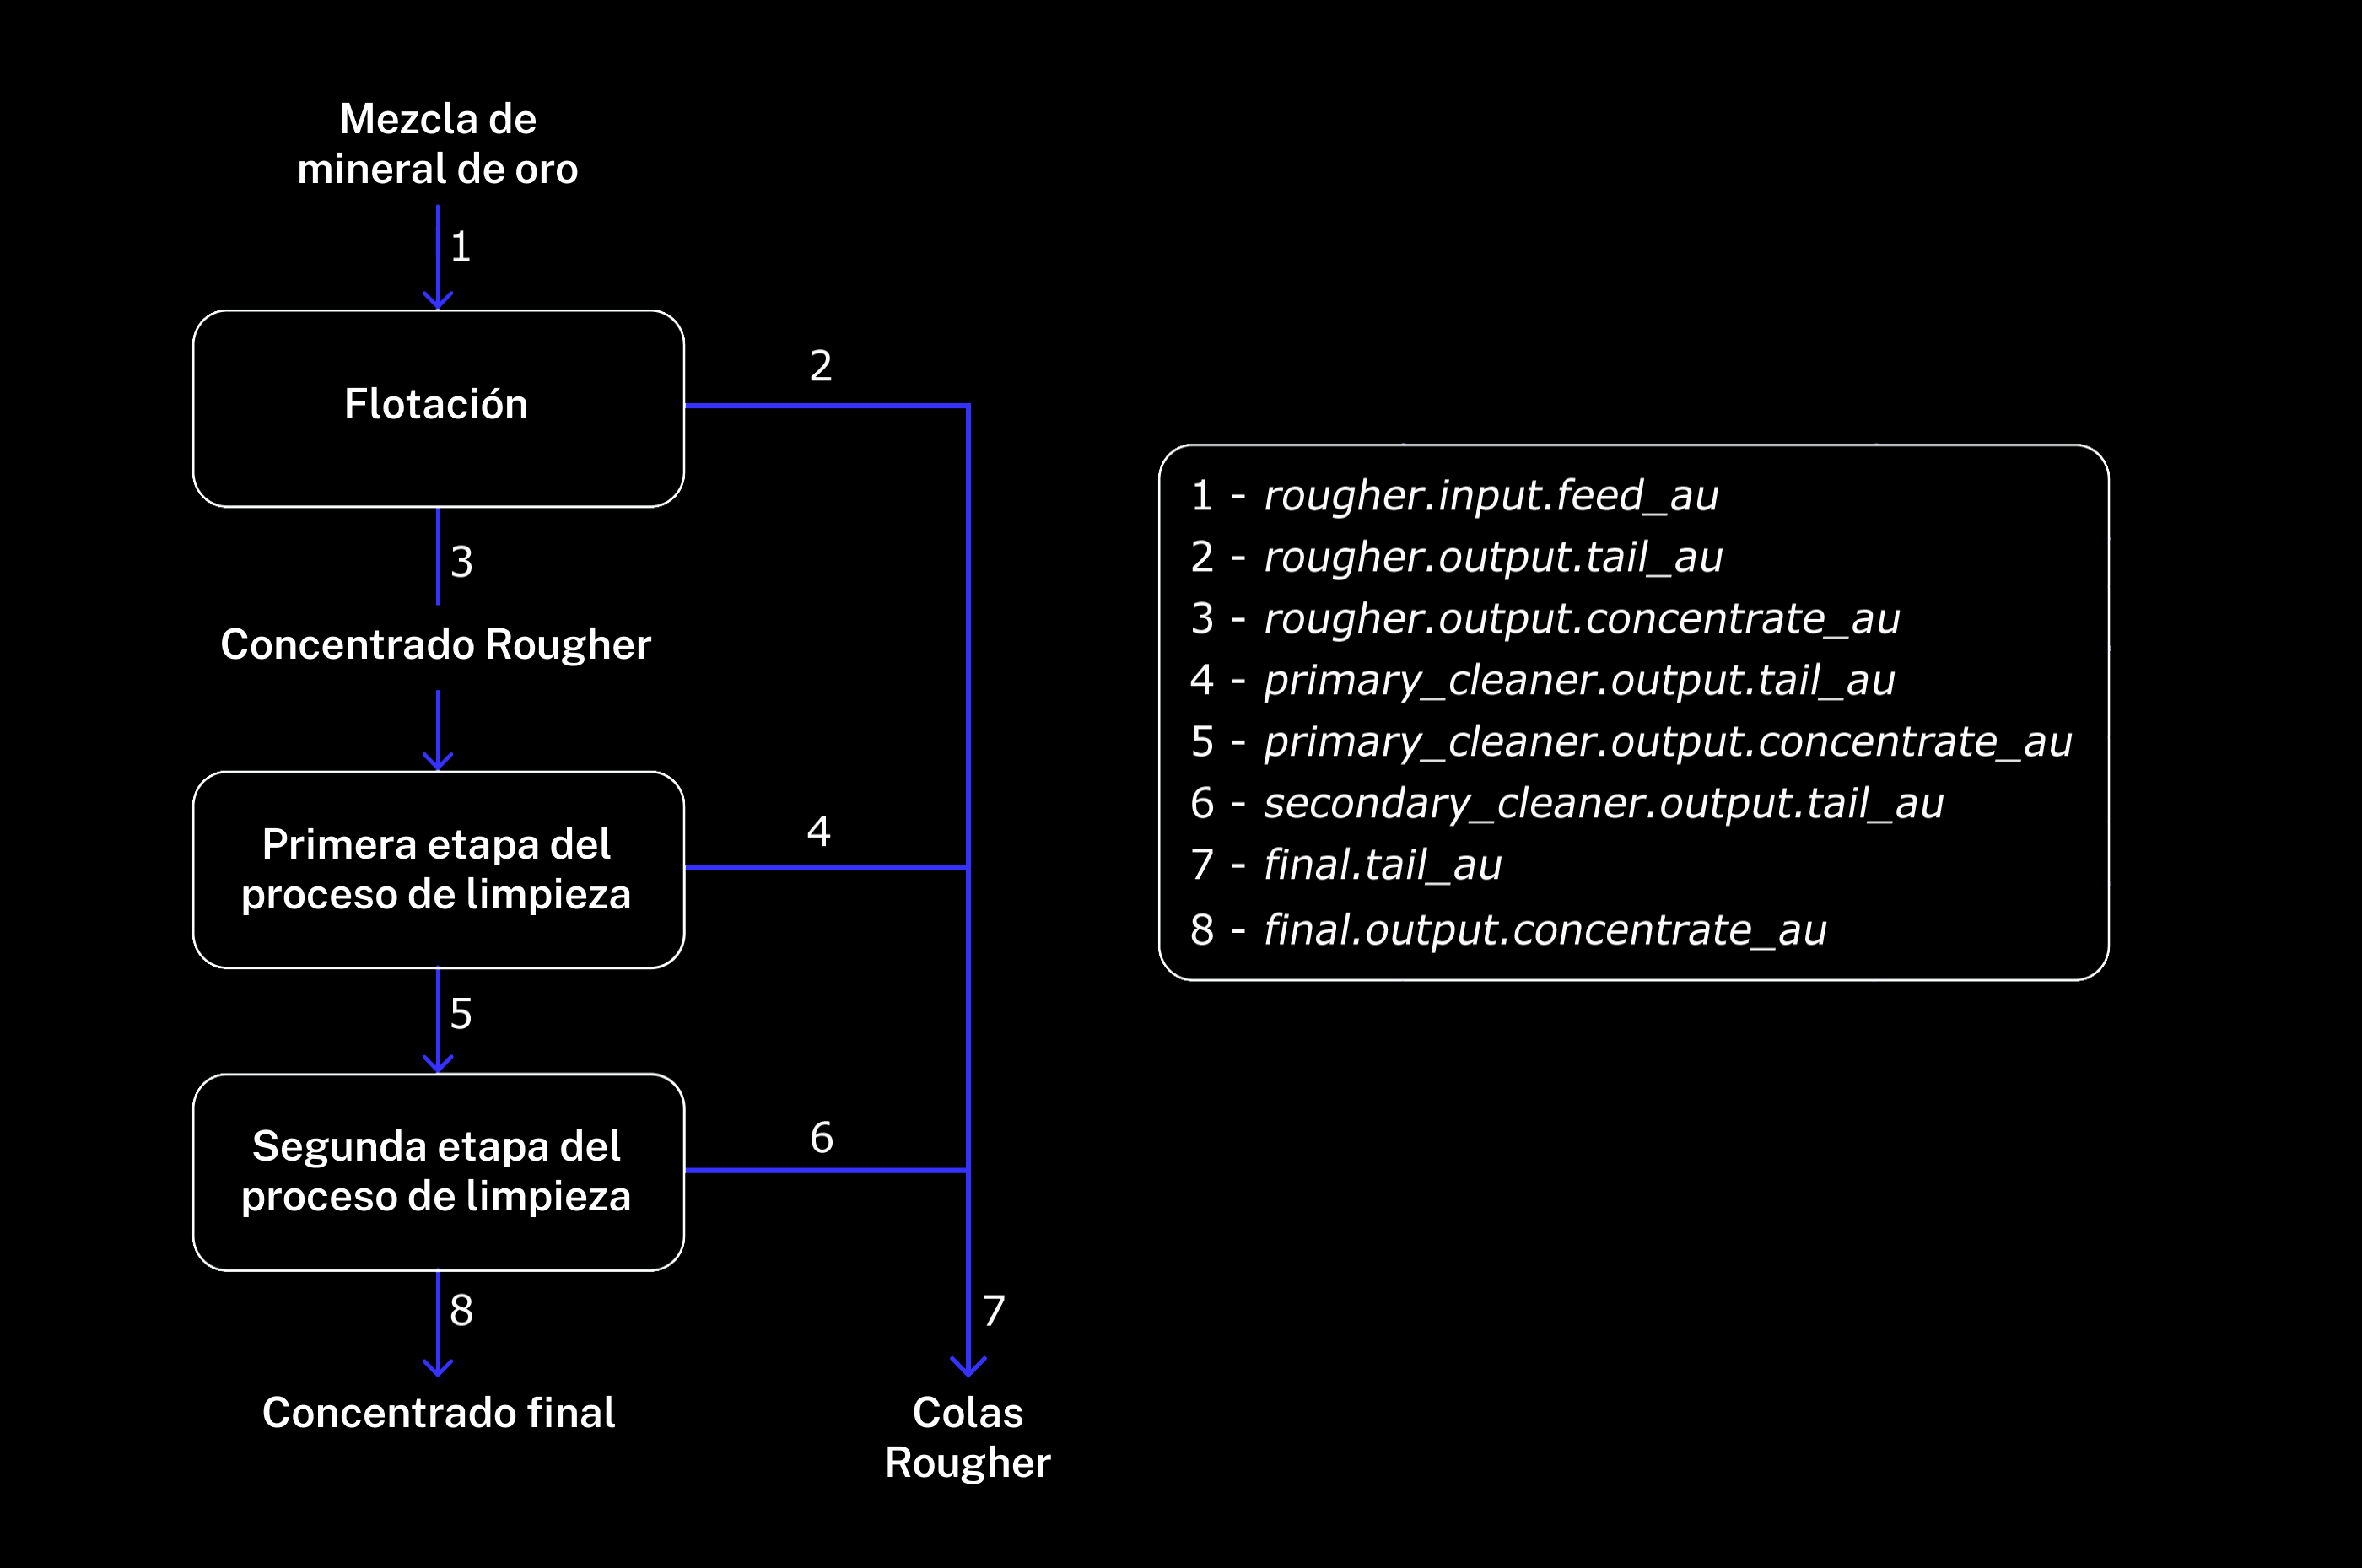

##### rougher.output.recovery

In [10]:
# Ahora filtro y elimino datos que puedan dar problemas en el cálculo del recovery
df_rougher = df_rougher[["rougher.output.concentrate_au", "rougher.input.feed_au", "rougher.output.tail_au", "rougher.output.recovery"]].copy()
df_rougher = df_rougher.rename(columns={"rougher.output.concentrate_au": "C", "rougher.input.feed_au": "F", "rougher.output.tail_au": "T", "rougher.output.recovery": "recovery_real"})

# Eliminar los valores donde C, F o T sean iguales a 0 para evitar divisiones por cero
df_rougher = df_rougher.drop(df_rougher[df_rougher["C"]==0].index)
df_rougher = df_rougher.drop(df_rougher[df_rougher["F"]==0].index)
df_rougher = df_rougher.drop(df_rougher[df_rougher["T"]==0].index)

# Eliminar filas con valores NaN
df_rougher = df_rougher.dropna()  

# Calcular la recuperación
df_rougher["recovery_estimation"] = (df_rougher["C"] * (df_rougher["F"] - df_rougher["T"])) / (df_rougher["F"] * (df_rougher["C"] - df_rougher["T"]))*100
df_rougher.info()

<class 'pandas.DataFrame'>
Index: 13967 entries, 0 to 16859
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   C                    13967 non-null  float64
 1   F                    13967 non-null  float64
 2   T                    13967 non-null  float64
 3   recovery_real        13967 non-null  float64
 4   recovery_estimation  13967 non-null  float64
dtypes: float64(5)
memory usage: 654.7 KB


In [11]:
# Ahora se calcula el MAE entre recovery_estimation y recovery_real para ver el error que se comete al usar la formula de recuperacion
mae = mean_absolute_error(df_rougher["recovery_real"], df_rougher["recovery_estimation"])
print(f"El error medio absoluto (MAE) es: {mae:.4f}")
 


El error medio absoluto (MAE) es: 0.0000


##### Conclusiones de 1.2. 
- Se observó que el recovery calculado vs el recovery de los datos, coincidecen correctamente ya que el error calculado es de  0.0000


#### 1.3. Analiza las características no disponibles en el conjunto de prueba. ¿Cuáles son estos parámetros? ¿Cuál es su tipo?

In [12]:
training_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 16860 entries, 0 to 16859
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype         
---  ------                                              --------------  -----         
 0   date                                                16860 non-null  datetime64[us]
 1   final.output.concentrate_ag                         16788 non-null  float64       
 2   final.output.concentrate_pb                         16788 non-null  float64       
 3   final.output.concentrate_sol                        16490 non-null  float64       
 4   final.output.concentrate_au                         16789 non-null  float64       
 5   final.output.recovery                               15339 non-null  float64       
 6   final.output.tail_ag                                16794 non-null  float64       
 7   final.output.tail_pb                                16677 non-null  float64       
 8   final.output.tail

In [13]:
test_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5856 entries, 0 to 5855
Data columns (total 53 columns):
 #   Column                                      Non-Null Count  Dtype         
---  ------                                      --------------  -----         
 0   date                                        5856 non-null   datetime64[us]
 1   primary_cleaner.input.sulfate               5554 non-null   float64       
 2   primary_cleaner.input.depressant            5572 non-null   float64       
 3   primary_cleaner.input.feed_size             5856 non-null   float64       
 4   primary_cleaner.input.xanthate              5690 non-null   float64       
 5   primary_cleaner.state.floatbank8_a_air      5840 non-null   float64       
 6   primary_cleaner.state.floatbank8_a_level    5840 non-null   float64       
 7   primary_cleaner.state.floatbank8_b_air      5840 non-null   float64       
 8   primary_cleaner.state.floatbank8_b_level    5840 non-null   float64       
 9   primary_cleaner.sta

In [14]:
columnas_faltantes = []
for column in training_data.columns:
    if column not in test_data.columns:
        columnas_faltantes.append(column)
print("Columnas faltantes en el conjunto de prueba:", columnas_faltantes)

df_temporal = training_data[columnas_faltantes]
df_temporal.info()

Columnas faltantes en el conjunto de prueba: ['final.output.concentrate_ag', 'final.output.concentrate_pb', 'final.output.concentrate_sol', 'final.output.concentrate_au', 'final.output.recovery', 'final.output.tail_ag', 'final.output.tail_pb', 'final.output.tail_sol', 'final.output.tail_au', 'primary_cleaner.output.concentrate_ag', 'primary_cleaner.output.concentrate_pb', 'primary_cleaner.output.concentrate_sol', 'primary_cleaner.output.concentrate_au', 'primary_cleaner.output.tail_ag', 'primary_cleaner.output.tail_pb', 'primary_cleaner.output.tail_sol', 'primary_cleaner.output.tail_au', 'rougher.calculation.sulfate_to_au_concentrate', 'rougher.calculation.floatbank10_sulfate_to_au_feed', 'rougher.calculation.floatbank11_sulfate_to_au_feed', 'rougher.calculation.au_pb_ratio', 'rougher.output.concentrate_ag', 'rougher.output.concentrate_pb', 'rougher.output.concentrate_sol', 'rougher.output.concentrate_au', 'rougher.output.recovery', 'rougher.output.tail_ag', 'rougher.output.tail_pb', '

Se aprecian cantidades de columnas diferentes entre el set de entrenamiento y el set de prueba. 

En los datos de prueba (test_data) faltan 34 columnas y dichas columnas son del tipo float.

Después de analizar los datos se entendió que el objetivo de este proyecto es entrenar el modelo usando las características que se indican test

#### 1.4. Realizar preprocesamiento de los datos


In [15]:
# Eliminar todos los valores NaN del conjunto de entrenamiento para evitar problemas en el entrenamiento de los modelos
training_data = training_data.dropna()

In [16]:
training_data.info()

<class 'pandas.DataFrame'>
Index: 11017 entries, 0 to 16859
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype         
---  ------                                              --------------  -----         
 0   date                                                11017 non-null  datetime64[us]
 1   final.output.concentrate_ag                         11017 non-null  float64       
 2   final.output.concentrate_pb                         11017 non-null  float64       
 3   final.output.concentrate_sol                        11017 non-null  float64       
 4   final.output.concentrate_au                         11017 non-null  float64       
 5   final.output.recovery                               11017 non-null  float64       
 6   final.output.tail_ag                                11017 non-null  float64       
 7   final.output.tail_pb                                11017 non-null  float64       
 8   final.output.tail_sol 

#### 2. Analisis de datos

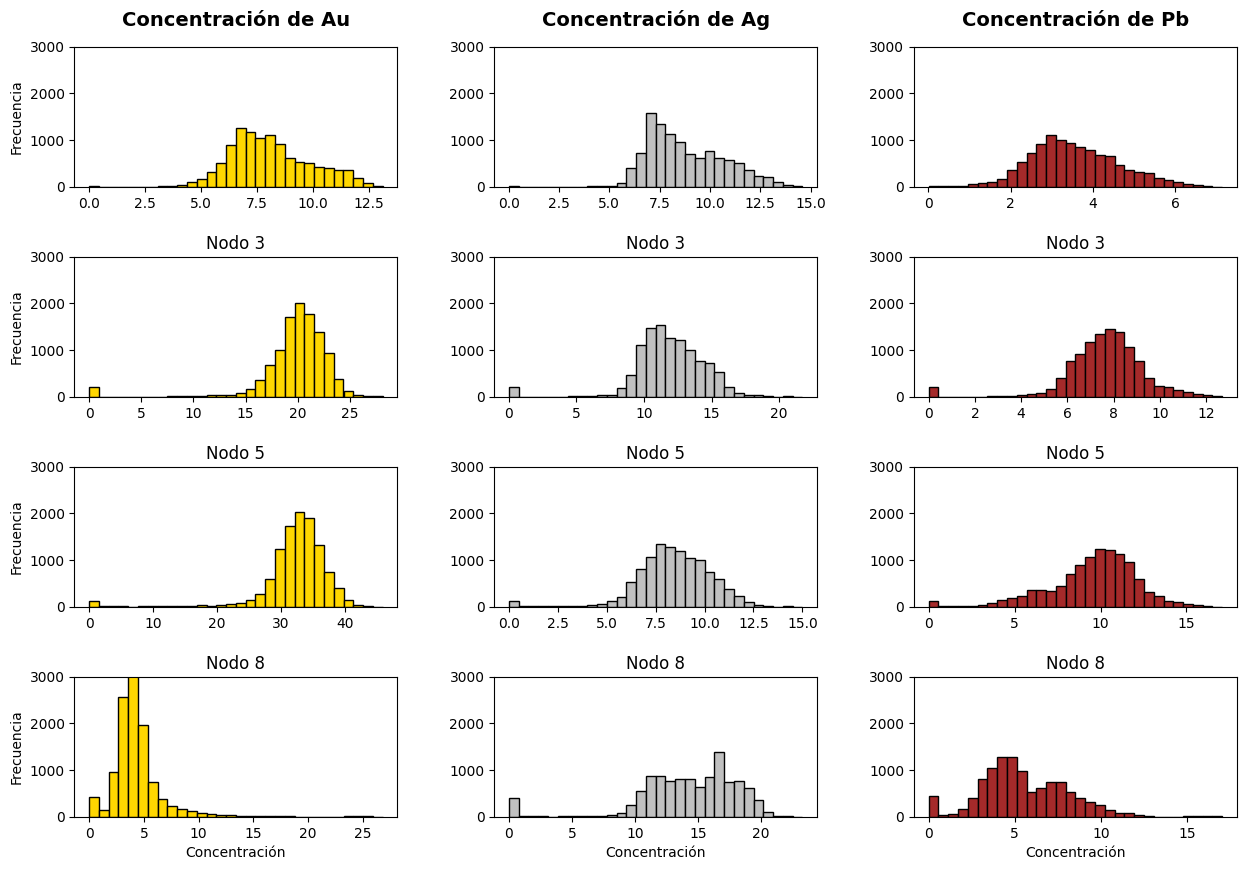

In [17]:
# 2.1.1. Figuras de concentración de Au, Ag y Pb en las diferentes etapas del proceso
figure, axes = plt.subplots(4, 3, figsize=(15, 10))

# Au
axes[0,0].hist(training_data["rougher.input.feed_au"], bins=30, color='gold', edgecolor='black')
axes[0,0].set_title("Nodo 1")
axes[1,0].hist(training_data["rougher.output.concentrate_au"], bins=30, color='gold', edgecolor='black')
axes[1,0].set_title("Nodo 3")
axes[2,0].hist(training_data["primary_cleaner.output.concentrate_au"], bins=30, color='gold', edgecolor='black')
axes[2,0].set_title("Nodo 5")
axes[3,0].hist(training_data["secondary_cleaner.output.tail_au"], bins=30, color='gold', edgecolor='black')
axes[3,0].set_title("Nodo 8")

axes[0,1].hist(training_data["rougher.input.feed_ag"], bins=30, color='silver', edgecolor='black')
axes[1,1].hist(training_data["rougher.output.concentrate_ag"], bins=30, color='silver', edgecolor='black')
axes[1,1].set_title("Nodo 3")
axes[2,1].hist(training_data["primary_cleaner.output.concentrate_ag"], bins=30, color='silver', edgecolor='black')
axes[2,1].set_title("Nodo 5")
axes[3,1].hist(training_data["secondary_cleaner.output.tail_ag"], bins=30, color='silver', edgecolor='black')
axes[3,1].set_title("Nodo 8")

axes[0,2].hist(training_data["rougher.input.feed_pb"], bins=30, color='brown', edgecolor='black')
axes[0,0].set_title("Nodo 1")
axes[1,2].hist(training_data["rougher.output.concentrate_pb"], bins=30, color='brown', edgecolor='black')
axes[1,2].set_title("Nodo 3")
axes[2,2].hist(training_data["primary_cleaner.output.concentrate_pb"], bins=30, color='brown', edgecolor='black')
axes[2,2].set_title("Nodo 5")
axes[3,2].hist(training_data["secondary_cleaner.output.tail_pb"], bins=30, color='brown', edgecolor='black')
axes[3,2].set_title("Nodo 8")

for ax in axes.flatten():
    ax.set_ylim(0, 3000)

axes[0,0].set_ylabel("Frecuencia")
axes[1,0].set_ylabel("Frecuencia")
axes[2,0].set_ylabel("Frecuencia")
axes[3,0].set_ylabel("Frecuencia")

axes[3,0].set_xlabel("Concentración")
axes[3,1].set_xlabel("Concentración")
axes[3,2].set_xlabel("Concentración")

figure.subplots_adjust(hspace=0.5 , wspace=0.3)

titulos_columnas = ['Concentración de Au', 'Concentración de Ag', 'Concentración de Pb']

# Iterar sobre los ejes de la primera fila (fila 0) y asignar el título
for ax, titulo in zip(axes[0], titulos_columnas):
    ax.set_title(titulo, fontsize=14, fontweight='bold', pad=15)


plt.show()


#### 2.2 Distribución del tamaño de partículas

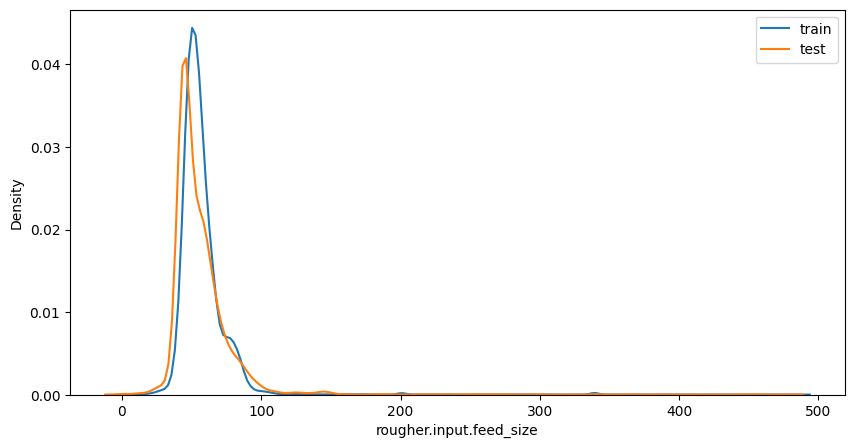

In [18]:
plt.figure(figsize=(10,5))

sns.kdeplot(
    training_data['rougher.input.feed_size'],
    label='train'
)

sns.kdeplot(
    test_data['rougher.input.feed_size'],
    label='test'
)

plt.legend()
plt.show()

#### 2.3. Considera las concentraciones totales de todas las sustancias en las diferentes etapas: materia prima, concentrado rougher y concentrado final. ¿Observas algún valor anormal en la distribución total? Si es así, ¿merece la pena eliminar esos valores de ambas muestras? Describe los resultados y elimina las anomalías.



In [19]:
training_data["feed_total"] = (
    training_data["rougher.input.feed_au"]
    + training_data["rougher.input.feed_ag"]
    + training_data["rougher.input.feed_pb"]
    + training_data["rougher.input.feed_sol"]
)

training_data["rougher_total"] = (
    training_data["rougher.output.concentrate_au"]
    + training_data["rougher.output.concentrate_ag"]
    + training_data["rougher.output.concentrate_pb"]
    + training_data["rougher.output.concentrate_sol"]
)

training_data["final_total"] = (
    training_data["final.output.concentrate_au"]
    + training_data["final.output.concentrate_ag"]
    + training_data["final.output.concentrate_pb"]
    + training_data["final.output.concentrate_sol"]
)

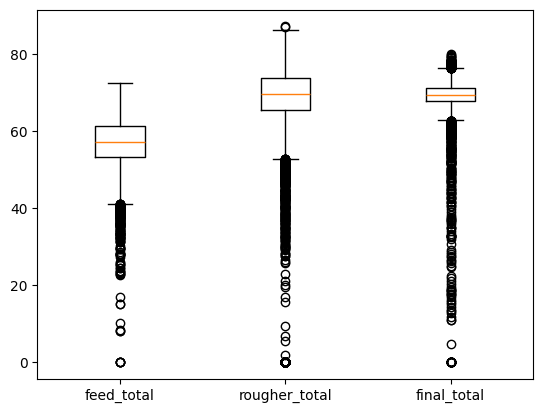

In [20]:
figure = plt.figure()
plt.boxplot(x=[training_data["feed_total"], training_data["rougher_total"], training_data["final_total"]], tick_labels=["feed_total", "rougher_total", "final_total"])
plt.show();

Nota: Es raro que existan valores de entrada cuyo total sea 0, ya que eso implicaría que no hay nada en la alimentación. Esto podría indicar un error en la recolección de datos o en el proceso de alimentación. Se decidió eliminar las filas donde esto ocurre

In [21]:
training_data = training_data[(training_data["feed_total"] > 0) & (training_data["rougher_total"] > 0) & (training_data["final_total"] > 0)]

In [22]:
training_data.info()

<class 'pandas.DataFrame'>
Index: 10784 entries, 0 to 16859
Data columns (total 90 columns):
 #   Column                                              Non-Null Count  Dtype         
---  ------                                              --------------  -----         
 0   date                                                10784 non-null  datetime64[us]
 1   final.output.concentrate_ag                         10784 non-null  float64       
 2   final.output.concentrate_pb                         10784 non-null  float64       
 3   final.output.concentrate_sol                        10784 non-null  float64       
 4   final.output.concentrate_au                         10784 non-null  float64       
 5   final.output.recovery                               10784 non-null  float64       
 6   final.output.tail_ag                                10784 non-null  float64       
 7   final.output.tail_pb                                10784 non-null  float64       
 8   final.output.tail_sol 

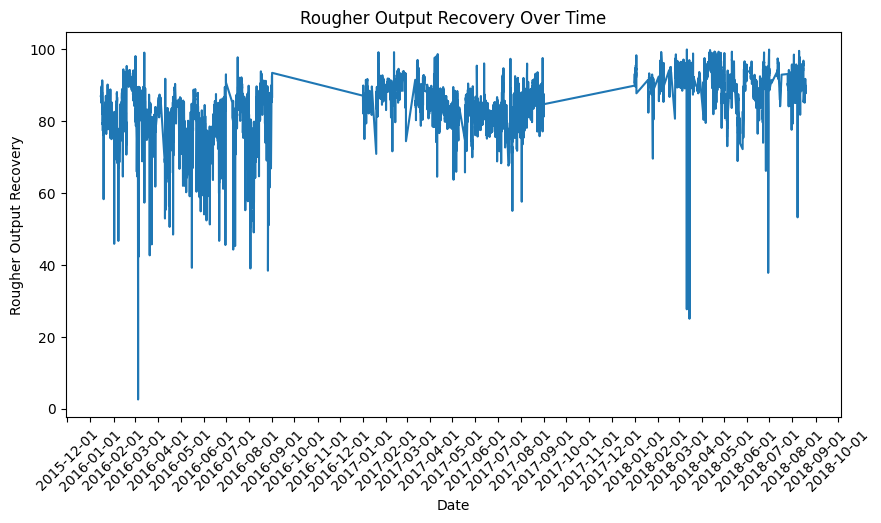

In [23]:
# Como los datos son una serie de tiempo, es interesante saber como es la distribución del target en el tiempo
figure = plt.figure(figsize=(10,5))
plt.plot(training_data["date"], training_data["rougher.output.recovery"])
plt.xticks(rotation=45)
plt.xticks(training_data["date"][::90])  # Establecer una marca cada 30 días
plt.xlabel("Date")
plt.ylabel("Rougher Output Recovery")
plt.title("Rougher Output Recovery Over Time")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())  # Marca principal cada mes
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) # Formato (ej. 'Jan', 'Feb')

plt.show()

In [24]:
# Evaluar deriva temporal, para esto se agrupa por año y se calcula la media, desviación estándar, mínimo y máximo del target de recuperación en el rougher
training_data["year"] = training_data["date"].dt.year

In [25]:
training_data.groupby("year")[
    "rougher.output.recovery"
].agg(["mean","std","min","max"])

,mean,std,min,max
year,,,,
2016,79.810662,7.917679,2.520854,99.132729
2017,85.000952,4.719573,55.050947,99.254694
2018,91.030480,4.748409,25.005887,100.000000


In [26]:
training_data.groupby("year")[
    "rougher.input.feed_au"
].agg(["mean","std"])

,mean,std
year,,
2016,7.872019,1.589584
2017,8.162377,1.711866
2018,8.408623,2.178290


In [27]:
# Conclusiones: 
# Se ven 3 comportamientos diferentes dependiendo de las fechas

#### 3. Construcción del modelo
#### 3.1. Construir la función para calcular sMAPE


In [28]:
def smape(y_true, y_pred):
    n = len(y_true)
    smape_value = (1/n) * sum(2* abs(y_true - y_pred) / (abs(y_true) + abs(y_pred))) *100
    return smape_value

# Hacer una función de scoring personalizada para usar SMAPE en cross_validate
smape_scorer = make_scorer(
    smape,
    greater_is_better=False
)

#### 3.2. Entrena diferentes modelos. Evalúalos aplicando la validación cruzada. Elige el mejor modelo y pruébalo utilizando la muestra de prueba. Facilita los resultados.

In [29]:
# Para entrenar los modelos se deben utilizar las columnas que se indican en el dataset de prueba como los features; y hay dos targets: 
# rougher.output.recovery y final.output.recovery. 
# Se debe entrenar un modelo para cada target.

columnas_de_interes = list(test_data.columns)

# Datos para la primera recuperación (rougher)
features = training_data[columnas_de_interes].drop(columns=["date"])
target_rougher = training_data["rougher.output.recovery"]
target_final = training_data["final.output.recovery"]

# Se usaran los datos escalados para el modelo lineal
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

In [30]:
# Preparar diccionario para guardar los datos, resultados y los modelos
resultados = {
    "data": {
        "features": features,
        "features_scaled": features_scaled,
        "target_rougher": target_rougher,
        "target_final": target_final,
        "scaler": scaler,
    },
    
    "recovery_rougher": {  
    
        "Modelo lineal": {
            "r2_score": None,
            "smape_score": None,
            "model": None,
            "predictions": None,
        },
        
        "Random Forest": {
            "r2_score": None,
            "smape_score": None,
            "model": None,
            "best_estimator": None,
            "best_depth": None,
            "predictions": None,
        },
        
        "Decision Tree": {
            "r2_score": None,
            "smape_score": None,
            "model": None,
            "best_depth": None,
            "predictions": None,
        },
    },
    
    "recovery_final": {  
       
        "Modelo lineal": {
            "r2_score": None,
            "smape_score": None,
            "model": None,
            "predictions": None,
        },
        
        "Random Forest": {
            "r2_score": None,
            "smape_score": None,
            "model": None,
            "best_estimator": None,
            "best_depth": None,
            "predictions": None,
        },
        
        "Decision Tree": {
            "r2_score": None,
            "smape_score": None,
            "model": None,
            "best_depth": None,
            "predictions": None,
        },
    },
}

##### 3.2.1. Modelos para el primer recovery (rougher):

In [31]:
# NOTA: 
# Me di cuenta de esto porque en las primeras iteraciones de entrenamiento, el modelo lineal obtenía un R2 negativo y un SMAPE muy alto; 
# Intenté usar este método de validación cruzada, pero el modelo lineal seguía obteniendo un R2 negativo y un SMAPE muy alto;
# cv = KFold(
#     n_splits=5,
#     shuffle=False,
# )

# Decidí cambiar a TimeSeriesSplit porque el dataset proviene de datos temporales; tras ver las series de tiempo del target y las tablas de promedios por año.
cv = TimeSeriesSplit(n_splits=5)

#### 3.2.1.1. Modelo lineal

In [32]:
model = LinearRegression()
scores = cross_validate(
        model,
        features_scaled, 
        target_rougher, 
        cv = cv, 
        scoring = {
                "r2": "r2",
                "sMAPE": smape_scorer}
)

r2_mean = scores["test_r2"].mean()
smape_mean = -scores["test_sMAPE"].mean()        

print(f"El r2 del modelo lineal: {r2_mean:.4f}")
print(f"El sMAPE del modelo lineal: {smape_mean:.4f}")

El r2 del modelo lineal: -1.7072
El sMAPE del modelo lineal: 8.8910


In [33]:
# Entrenar el modelo lineal con los datos completos para luego guardarlo en el diccionario
model = LinearRegression()
model.fit(features_scaled, target_rougher)
predicted = model.predict(features_scaled)

# # Guardar los resultados y el modelo en el diccionario
resultados["recovery_rougher"]["Modelo lineal"]["r2_score"] = r2_mean
resultados["recovery_rougher"]["Modelo lineal"]["smape_score"] = smape_mean
resultados["recovery_rougher"]["Modelo lineal"]["model"] = model
resultados["recovery_rougher"]["Modelo lineal"]["predictions"] = predicted

print(scores["test_r2"])
print(-scores["test_sMAPE"])

[-4.10987796 -0.47972755 -1.45587567 -1.20251351 -1.28791787]
[15.78389535  7.1835497   5.53851835  8.75228999  7.19674221]


#### 3.2.1.2. Random Forest

In [34]:
best_r2_score = -float('inf')
best_smape_score = float('inf')

best_estimator = 0
best_depth = 0
best_model = None

n_estimators = [100]
max_depths = [2, 4, 8]

for n in n_estimators:
    for d in max_depths:
        model = RandomForestRegressor(n_estimators=n, max_depth=d, random_state=12345)
        scores = cross_validate(
            model,
            features, 
            target_rougher, 
            cv = cv, 
            scoring = {
                    "r2": "r2",
                    "sMAPE": smape_scorer}
        )
        
        r2_mean = scores["test_r2"].mean()
        smape_mean = -scores["test_sMAPE"].mean()
        
        print(f"r2_mean: {r2_mean:.4f}, smape_mean: {smape_mean:.4f} con n_estimators={n} y max_depth={d}")
        
        if r2_mean > best_r2_score:
            best_r2_score = r2_mean
            best_smape_score = smape_mean
            best_estimator = n
            best_depth = d
            
print(f"Mejores scores: r2 = {best_r2_score:.4f}, smape = {best_smape_score:.4f} con n_estimators={best_estimator} y max_depth={best_depth}")    

r2_mean: -0.3492, smape_mean: 6.3727 con n_estimators=100 y max_depth=2
r2_mean: -0.2157, smape_mean: 6.0620 con n_estimators=100 y max_depth=4
r2_mean: -0.2598, smape_mean: 6.1046 con n_estimators=100 y max_depth=8
Mejores scores: r2 = -0.2157, smape = 6.0620 con n_estimators=100 y max_depth=4


In [35]:
# Entrenar el modelo Random Forest con los datos completos para luego guardarlo en el diccionario
model = RandomForestRegressor(n_estimators=best_estimator, max_depth=best_depth, random_state=12345)
model.fit(features, target_rougher)
predicted = model.predict(features)

resultados["recovery_rougher"]["Random Forest"]["r2_score"] = best_r2_score
resultados["recovery_rougher"]["Random Forest"]["smape_score"] = best_smape_score
resultados["recovery_rougher"]["Random Forest"]["best_estimator"] = best_estimator
resultados["recovery_rougher"]["Random Forest"]["best_depth"] = best_depth
resultados["recovery_rougher"]["Random Forest"]["model"] = model
resultados["recovery_rougher"]["Random Forest"]["predictions"] = predicted

print("R2 train:", r2_score(target_rougher, predicted))
print("sMAPE train:", smape(target_rougher, predicted))


R2 train: 0.6271743088933458
sMAPE train: 3.8608921769628823


#### 3.2.1.3. Decision Tree Regressor

In [36]:
best_depth = 0
best_r2_score = -float('inf')
best_smape_score = float('inf')

depths = [2, 4, 8, 10]
for d in depths:
    model = DecisionTreeRegressor(max_depth=d, random_state=12345)
    scores = cross_validate(
        model,
        features, 
        target_rougher, 
        cv = cv, 
        scoring = {
                "r2": "r2",
                "sMAPE": smape_scorer}
    )
    mean_r2 = scores["test_r2"].mean()
    mean_smape = -scores["test_sMAPE"].mean()
    print(f"max_depth: {d}, r2_mean: {mean_r2:.4f}, smape_mean: {mean_smape:.4f}")
    if mean_r2 > best_r2_score:
        best_r2_score = mean_r2
        best_smape_score = mean_smape
        best_depth = d
        
print(f"Mejores scores: r2 = {best_r2_score:.4f}, smape = {best_smape_score:.4f} con max_depth={best_depth}")

max_depth: 2, r2_mean: -0.4781, smape_mean: 6.5539
max_depth: 4, r2_mean: -0.2346, smape_mean: 5.9158
max_depth: 8, r2_mean: -1.2218, smape_mean: 7.0614
max_depth: 10, r2_mean: -1.3122, smape_mean: 7.2309
Mejores scores: r2 = -0.2346, smape = 5.9158 con max_depth=4


In [37]:
# Entrenar el modelo Decision Tree con los datos completos para luego guardarlo en el diccionario
model = DecisionTreeRegressor(max_depth=best_depth, random_state=12345)
model.fit(features, target_rougher)
predicted = model.predict(features)

resultados["recovery_rougher"]["Decision Tree"]["r2_score"] = best_r2_score
resultados["recovery_rougher"]["Decision Tree"]["smape_score"] = best_smape_score
resultados["recovery_rougher"]["Decision Tree"]["best_depth"] = best_depth
resultados["recovery_rougher"]["Decision Tree"]["model"] = model
resultados["recovery_rougher"]["Decision Tree"]["predictions"] = predicted

print("R2 train:", r2_score(target_rougher, predicted))
print("sMAPE train:", smape(target_rougher, predicted))

R2 train: 0.5804320400567203
sMAPE train: 4.1074849066510914


#### 3.2.2. Modelos del segundo recovery (final):


#### 3.2.2.1. Modelo lineal

In [38]:
model = LinearRegression()
scores = cross_validate(
        model,
        features_scaled, 
        target_final, 
        cv = cv, 
        scoring = {
                "r2": "r2",
                "sMAPE": smape_scorer}
)

r2_mean = scores["test_r2"].mean()
smape_mean = -scores["test_sMAPE"].mean()        

print(f"El r2 del modelo lineal: {r2_mean:.4f}")
print(f"El sMAPE del modelo lineal: {smape_mean:.4f}")


El r2 del modelo lineal: -0.3787
El sMAPE del modelo lineal: 10.1872


In [39]:
# Entrenar el modelo lineal con los datos completos para luego guardarlo en el diccionario
model = LinearRegression()
model.fit(features_scaled, target_final)
predicted = model.predict(features_scaled)

# # Guardar los resultados y el modelo en el diccionario
resultados["recovery_final"]["Modelo lineal"]["r2_score"] = r2_mean
resultados["recovery_final"]["Modelo lineal"]["smape_score"] = smape_mean
resultados["recovery_final"]["Modelo lineal"]["model"] = model
resultados["recovery_final"]["Modelo lineal"]["predictions"] = predicted

print("R2 train:", r2_score(target_final, predicted))
print("sMAPE train:", smape(target_final, predicted))

R2 train: 0.37985877644334576
sMAPE train: 6.8523033191820275


#### 3.2.2.2. Random Forest

In [40]:
best_r2_score = 0
best_smape_score = float('inf')

best_estimator = 0
best_depth = 0
best_model = None

# n_estimators = [100, 200, 300]
# max_depths = [20, 25, 30]

n_estimators = [100]
max_depths = [2,4,6]
    
for n in n_estimators:
    for d in max_depths:
        model = RandomForestRegressor(n_estimators=n, max_depth=d, random_state=12345)
        scores = cross_validate(
            model,
            features, 
            target_final, 
            cv = cv, 
            scoring = {
                    "r2": "r2",
                    "sMAPE": smape_scorer}
        )
        
        r2_mean = scores["test_r2"].mean()
        smape_mean = -scores["test_sMAPE"].mean()
        
        print(f"r2_mean: {r2_mean:.4f}, smape_mean: {smape_mean:.4f} con n_estimators={n} y max_depth={d}")
        
        if r2_mean > best_r2_score:
            best_r2_score = r2_mean
            best_smape_score = smape_mean
            best_estimator = n
            best_depth = d
            
print(f"Mejores scores: r2 = {best_r2_score}, smape = {best_smape_score} con n_estimators={best_estimator} y max_depth={best_depth}")    

r2_mean: -0.0324, smape_mean: 8.6829 con n_estimators=100 y max_depth=2
r2_mean: -0.0032, smape_mean: 8.6072 con n_estimators=100 y max_depth=4
r2_mean: 0.0350, smape_mean: 8.4696 con n_estimators=100 y max_depth=6
Mejores scores: r2 = 0.03504556805151391, smape = 8.469577271707916 con n_estimators=100 y max_depth=6


In [41]:
# Entrenar el modelo Random Forest con los datos completos para luego guardarlo en el diccionario
model = RandomForestRegressor(n_estimators=best_estimator, max_depth=best_depth, random_state=12345)
model.fit(features, target_final)
predicted = model.predict(features)

resultados["recovery_final"]["Random Forest"]["r2_score"] = best_r2_score
resultados["recovery_final"]["Random Forest"]["smape_score"] = best_smape_score
resultados["recovery_final"]["Random Forest"]["best_estimator"] = best_estimator
resultados["recovery_final"]["Random Forest"]["best_depth"] = best_depth
resultados["recovery_final"]["Random Forest"]["model"] = model
resultados["recovery_final"]["Random Forest"]["predictions"] = predicted

print("R2 train:", r2_score(target_final, predicted))
print("sMAPE train:", smape(target_final, predicted))

R2 train: 0.5652116405930989
sMAPE train: 5.788202639606306


#### 3.2.2.3. Decision Tree Regressor

In [42]:
best_depth = 0
best_r2_score = -float('inf')
best_smape_score = float('inf')

depths = [2, 4, 8, 10]
for d in depths:
    model = DecisionTreeRegressor(max_depth=d, random_state=12345)
    scores = cross_validate(
        model,
        features, 
        target_rougher, 
        cv = cv, 
        scoring = {
                "r2": "r2",
                "sMAPE": smape_scorer}
    )
    mean_r2 = scores["test_r2"].mean()
    mean_smape = -scores["test_sMAPE"].mean()
    print(f"max_depth: {d}, r2_mean: {mean_r2:.4f}, smape_mean: {mean_smape:.4f}")
    if mean_r2 > best_r2_score:
        best_r2_score = mean_r2
        best_smape_score = mean_smape
        best_depth = d
        
print(f"Mejores scores: r2 = {best_r2_score:.4f}, smape = {best_smape_score:.4f} con max_depth={best_depth}")

max_depth: 2, r2_mean: -0.4781, smape_mean: 6.5539
max_depth: 4, r2_mean: -0.2346, smape_mean: 5.9158
max_depth: 8, r2_mean: -1.2218, smape_mean: 7.0614
max_depth: 10, r2_mean: -1.3122, smape_mean: 7.2309
Mejores scores: r2 = -0.2346, smape = 5.9158 con max_depth=4


In [43]:
# Entrenar el modelo Decision Tree con los datos completos para luego guardarlo en el diccionario
model = DecisionTreeRegressor(max_depth=best_depth, random_state=12345)
model.fit(features, target_final)
predicted = model.predict(features)

resultados["recovery_final"]["Decision Tree"]["r2_score"] = best_r2_score
resultados["recovery_final"]["Decision Tree"]["smape_score"] = best_smape_score
resultados["recovery_final"]["Decision Tree"]["best_depth"] = best_depth
resultados["recovery_final"]["Decision Tree"]["model"] = model
resultados["recovery_final"]["Decision Tree"]["predictions"] = predicted

print("R2 train:", r2_score(target_final, predicted))
print("sMAPE train:", smape(target_final, predicted))

R2 train: 0.3909232904254907
sMAPE train: 6.818958736808085


#### 3.2.3. Calculo del sMAPE final

In [44]:
recovery_rougher = resultados["recovery_rougher"]["Decision Tree"]["predictions"]
recovery_final = resultados["recovery_final"]["Decision Tree"]["predictions"]
sMAPE_final = 0.25 * smape(target_rougher, recovery_rougher) + 0.75 * smape(target_final, recovery_final)
print(f"sMAPE final: {sMAPE_final:.4f}%")

sMAPE final: 6.1411%


In [45]:
# Guardar los datos
dump(resultados, "resultados.joblib")

['resultados.joblib']

#### Conclusiones hasta el momento.
- Se entrenaron tres modelos para cada recovery del proceso.
- Se observaron valores negativos del R2; estos pueden deberse a la temporalidad de los datos.
- El valor del sMAPE final fue del 6.14%; para el primer recovery el mejor smape se obtuvo con el modelo del Decsion Tree con un valor de 4.10% y para el 2do recovery se obtuvo un snape de 6.81%. Ambos fueron mucho mejores que el smape obtenido por los otros modelos.
- Se almacenaron los resultados así como el modelo usando joblib para usarlos en las pruebas del modelo.
- Tras varias evaluaciones y analizar las series temporales; se sugiere entrenar modelos con los datos acotados a las fechas del proceso. Si se entrena un modelo con todo el set de datos (entre 2016 y 2018) y luego se intenta probar el modelo con datos de fechas del 2016 el modelo fallará; esto debido a que las series temporales muestran diferencias en los promedios de recuperación dependiendo de las fechas (esto no se hará para este ejercicio dados los objetivos del proyecto)

#### 3.2.4 Usar modelos entrenados para hacer las pruebas y contrastar resultados

#### 3.2.4.1. Cargar datos de prueba

In [46]:
# A continuación, se ejecutarán las predicciones sobre el dataset de prueba y posteriormente, 
# comprobaré el porcentaje de aciertos aprovechando que cuento con el dataset de datos completos.
# NOTA: Esto suele hacerse en un notebook aparte; pero lo dejo acá para no tener multiples cuadernos para este proyecto.

#9.1.1. preparo los datos; features y targets
full_data = load_data(folder, "gold_recovery_full.csv")
full_data["date"] = pd.to_datetime(full_data["date"], format="%Y-%m-%d %H:%M:%S")
df_con_recoveries = pd.merge(test_data, full_data, on="date", how="left", suffixes=("", '_y'))
columnas_a_mantener = [col for col in df_con_recoveries.columns if not col.endswith('_y') or col in test_data.columns]
df_con_recoveries = df_con_recoveries[columnas_a_mantener]
df_con_recoveries.info()

<class 'pandas.DataFrame'>
RangeIndex: 5856 entries, 0 to 5855
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype         
---  ------                                              --------------  -----         
 0   date                                                5856 non-null   datetime64[us]
 1   primary_cleaner.input.sulfate                       5554 non-null   float64       
 2   primary_cleaner.input.depressant                    5572 non-null   float64       
 3   primary_cleaner.input.feed_size                     5856 non-null   float64       
 4   primary_cleaner.input.xanthate                      5690 non-null   float64       
 5   primary_cleaner.state.floatbank8_a_air              5840 non-null   float64       
 6   primary_cleaner.state.floatbank8_a_level            5840 non-null   float64       
 7   primary_cleaner.state.floatbank8_b_air              5840 non-null   float64       
 8   primary_cleaner.sta

In [47]:
# Busco los recoveries reales de los datos completos (haciendo un merge de las fechas de los datos de prueba con los datos completos)

# eliminar valores negativos o con cero
df_con_recoveries["feed_total"] = (
    df_con_recoveries["rougher.input.feed_au"]
    + df_con_recoveries["rougher.input.feed_ag"]
    + df_con_recoveries["rougher.input.feed_pb"]
    + df_con_recoveries["rougher.input.feed_sol"]
)

df_con_recoveries["rougher_total"] = (
    df_con_recoveries["rougher.output.concentrate_au"]
    + df_con_recoveries["rougher.output.concentrate_ag"]
    + df_con_recoveries["rougher.output.concentrate_pb"]
    + df_con_recoveries["rougher.output.concentrate_sol"]
)

df_con_recoveries["final_total"] = (
    df_con_recoveries["final.output.concentrate_au"]
    + df_con_recoveries["final.output.concentrate_ag"]
    + df_con_recoveries["final.output.concentrate_pb"]
    + df_con_recoveries["final.output.concentrate_sol"]
)

df_con_recoveries = df_con_recoveries[(df_con_recoveries["feed_total"] > 0) & (df_con_recoveries["rougher_total"] > 0) & (df_con_recoveries["final_total"] > 0)]

# eliminar nans para evitar problemas en el cálculo de los scores
df_con_recoveries = df_con_recoveries.dropna()

features = df_con_recoveries[columnas_de_interes].drop(columns=["date"])
features.info()

recovery_rougher_real = df_con_recoveries["rougher.output.recovery"]
recovery_final_real = df_con_recoveries["final.output.recovery"]

<class 'pandas.DataFrame'>
Index: 4969 entries, 0 to 5855
Data columns (total 52 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   primary_cleaner.input.sulfate               4969 non-null   float64
 1   primary_cleaner.input.depressant            4969 non-null   float64
 2   primary_cleaner.input.feed_size             4969 non-null   float64
 3   primary_cleaner.input.xanthate              4969 non-null   float64
 4   primary_cleaner.state.floatbank8_a_air      4969 non-null   float64
 5   primary_cleaner.state.floatbank8_a_level    4969 non-null   float64
 6   primary_cleaner.state.floatbank8_b_air      4969 non-null   float64
 7   primary_cleaner.state.floatbank8_b_level    4969 non-null   float64
 8   primary_cleaner.state.floatbank8_c_air      4969 non-null   float64
 9   primary_cleaner.state.floatbank8_c_level    4969 non-null   float64
 10  primary_cleaner.state.floatb

In [48]:
# Cargar el primer modelo de recuperación (rougher) y hacer las predicciones sobre el dataset de prueba
model = resultados["recovery_rougher"]["Decision Tree"]["model"]
recovery_rougher_predicted = model.predict(features)
r2_score_rougher = r2_score(recovery_rougher_real, recovery_rougher_predicted)
smape_score_rougher = smape(recovery_rougher_real, recovery_rougher_predicted)
print(f"R2 score para recovery rougher: {r2_score_rougher:.4f}")
print(f"sMAPE score para recovery rougher: {smape_score_rougher:.4f}%")


R2 score para recovery rougher: -0.8107
sMAPE score para recovery rougher: 6.6208%


In [49]:
# Cargar el segundo modelo de recuperación (final) y hacer las predicciones sobre el dataset de prueba
model = resultados["recovery_final"]["Decision Tree"]["model"]
recovery_final_predicted = model.predict(features)
r2_score_final = r2_score(recovery_final_real, recovery_final_predicted)
smape_score_final = smape(recovery_final_real, recovery_final_predicted)
print(f"R2 score para recovery final: {r2_score_final:.4f}")
print(f"sMAPE score para recovery final: {smape_score_final:.4f}%")

R2 score para recovery final: -0.3518
sMAPE score para recovery final: 8.5781%


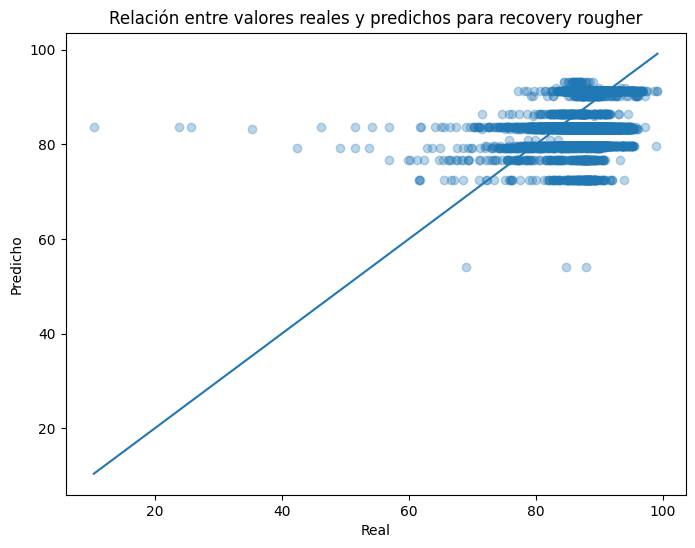

In [50]:
# Relación entre los valores reales y los valores predichos para el recovery del rougher, para esto se hace un scatter plot con los valores reales en el eje x y los valores predichos en el eje y; además se añade una línea diagonal que representa la situación ideal donde los valores predichos son iguales a los valores reales.

plt.figure(figsize=(8,6))
plt.scatter(recovery_rougher_real,
            recovery_rougher_predicted,
            alpha=0.3)

plt.xlabel("Real")
plt.ylabel("Predicho")
plt.plot(
    [recovery_rougher_real.min(), recovery_rougher_real.max()],
    [recovery_rougher_real.min(), recovery_rougher_real.max()]
)
plt.title("Relación entre valores reales y predichos para recovery rougher")
plt.show()

Conclusiones:
- El modelo Decision Tree fue el que mejor desempeño tuvo para predecir tanto el recovery del rougher como el recovery final
- En el gráfico de relación entre valores predichos y valores reales se puede observar que en general existe una buena relación entre ambos valores; sin embargo, también se observa que los valores bajos, tienden a ser sobreestimados y los valores altos subestimados; parte de este problema se debe a la distribución de los datos en series temporales; también porque el valor del target está limitado a valores entre 0 y 100 % de recuperación. 
- Es posible que se puedan mejorar los ajustes y predicciones del modelo si se entrena y se prueba con fechas dentro del mismo rango de tiempo. Anteriormente se mostró un gráfico y tablas que muestran que las recuperaciones cambian con los años; las medias van en aumento, eso da indicios en cambios en los procesos o la calidad de las entradas.
